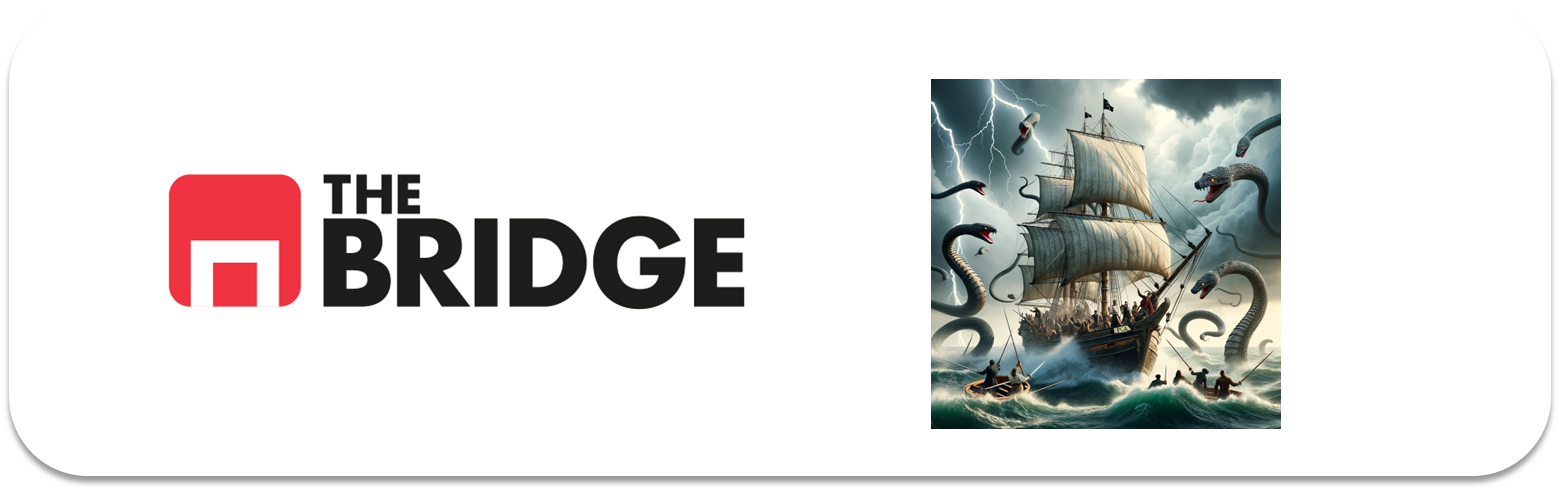

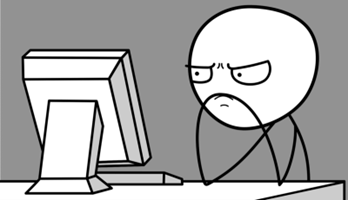

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, balanced_accuracy_score,
                             accuracy_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, SelectFromModel
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
rf=RandomForestClassifier(max_depth=5,random_state=SEED)
results=[]
def evaluate(name,model,X=X if 'X' in globals() else None):
    scores=cross_val_score(model,X_train,y_train,cv=cv,scoring='balanced_accuracy')
    model.fit(X_train,y_train)
    results.append({'metodo':name,'CV':scores.mean(),'CV_std':scores.std()})
    display(pd.DataFrame(results))
    return model

### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df=pd.read_csv('data/breastcancer-winsconsin.csv')
display(df.head()); df.info()
print('Medidas de tamaño y forma, resumidas como mean, se y worst: cabe esperar redundancia entre radio, área y perímetro.')

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [3]:
df=df.drop(columns=['id','Unnamed: 32'])
assert df.notna().all().all()

### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

In [4]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns='diagnosis'),df.diagnosis,test_size=.2,stratify=df.diagnosis,random_state=SEED)
display(y_train.value_counts(normalize=True)); print('B benigno, M maligno; balanced accuracy pondera ambas clases igual.')

diagnosis
B    0.626374
M    0.373626
Name: proportion, dtype: float64

B benigno, M maligno; balanced accuracy pondera ambas clases igual.


### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

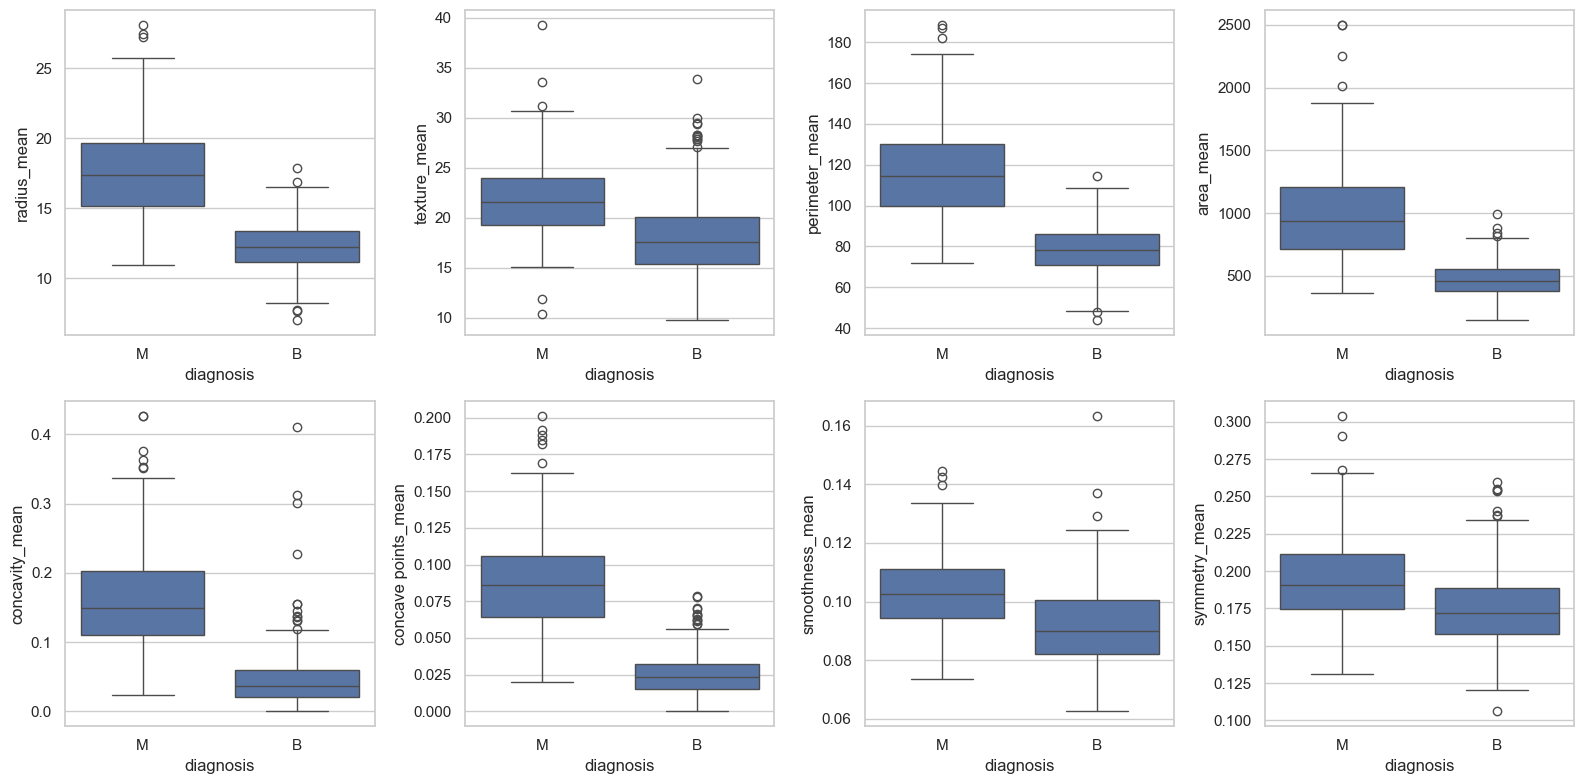

Retengo variables de tamaño/textura/concavidad que muestran separación visual. Selección exploratoria con train, nunca test.


In [5]:
visual_candidates=['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','concave points_mean','smoothness_mean','symmetry_mean']
fig,axes=plt.subplots(2,4,figsize=(16,8))
for c,ax in zip(visual_candidates,axes.flat): sns.boxplot(x=y_train,y=X_train[c],ax=ax)
plt.tight_layout(); plt.show()
visual_features=['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','concave points_mean']
print('Retengo variables de tamaño/textura/concavidad que muestran separación visual. Selección exploratoria con train, nunca test.')

### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

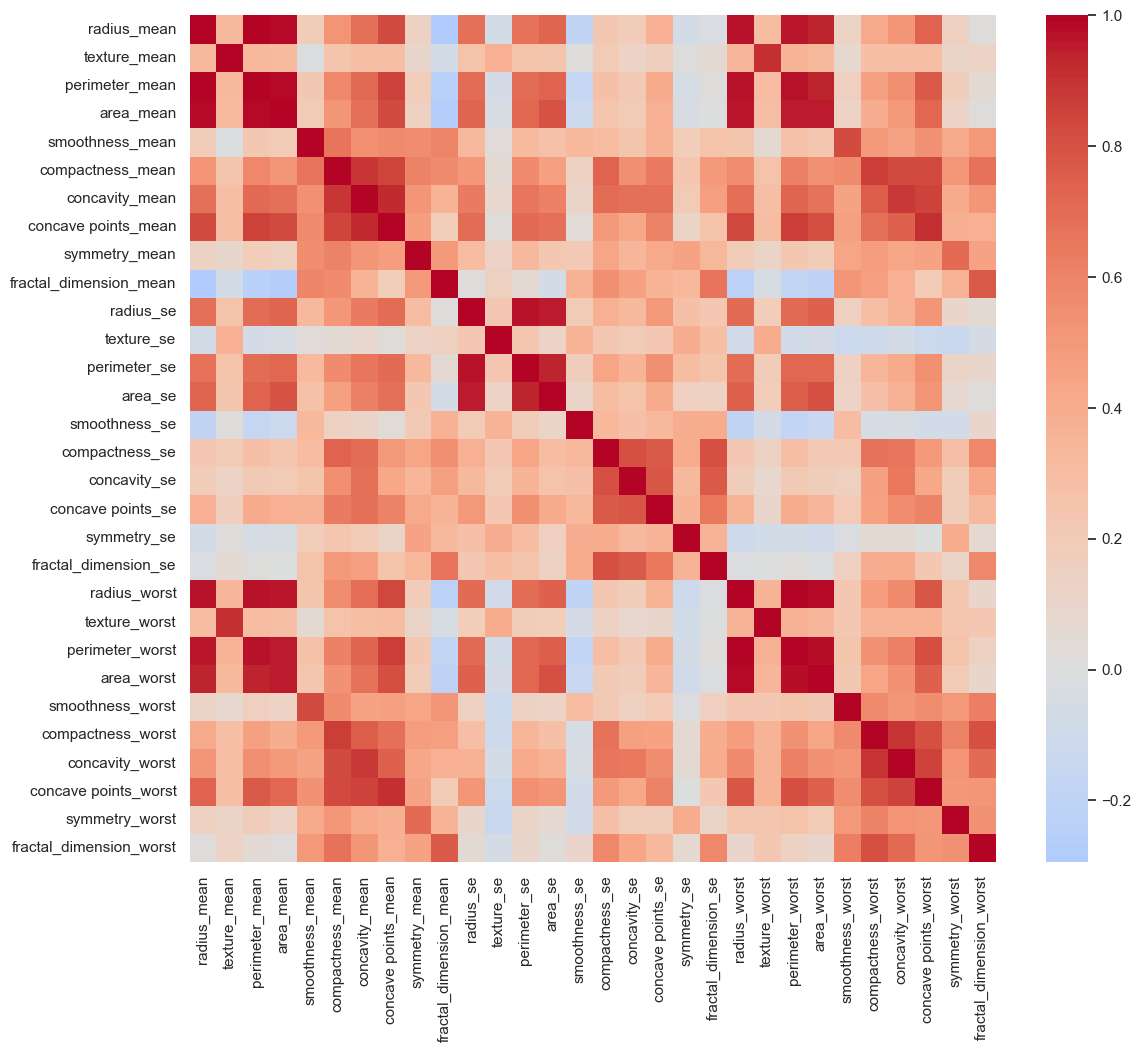

Radio, perímetro y área están correlacionados; reducirlos puede simplificar sin perder tanta información.


In [6]:
corr=X_train.corr()
plt.figure(figsize=(13,11)); sns.heatmap(corr,cmap='coolwarm',center=0); plt.show()
print('Radio, perímetro y área están correlacionados; reducirlos puede simplificar sin perder tanta información.')

### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

In [7]:
baseline=evaluate('Todas',clone(rf))
baseline_test=balanced_accuracy_score(y_test,baseline.predict(X_test))
print('Baseline test:',baseline_test)

,metodo,CV,CV_std
0,Todas,0.963003,0.023833


Baseline test: 0.9642857142857143


### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

['radius_mean', 'texture_mean', 'concavity_mean']

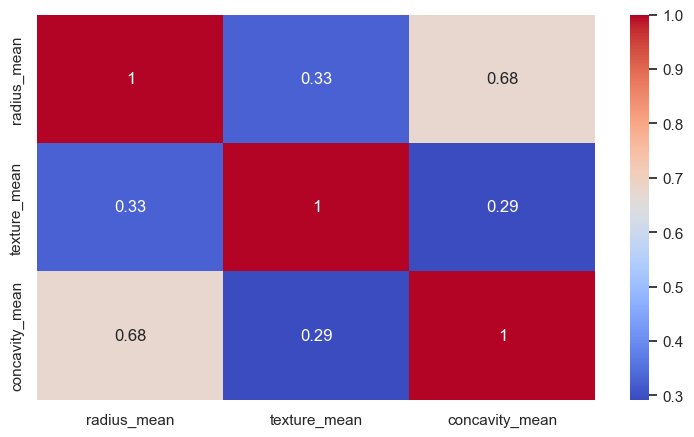

In [8]:
selected_visual=[]
for c in visual_features:
    if all(abs(corr.loc[c,p])<.9 for p in selected_visual): selected_visual.append(c)
display(selected_visual)
sns.heatmap(X_train[selected_visual].corr(),annot=True,cmap='coolwarm'); plt.show()

### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

In [9]:
from sklearn.compose import ColumnTransformer
visual_model=make_pipeline(ColumnTransformer([('visual','passthrough',selected_visual)],remainder='drop'),clone(rf))
visual_model=evaluate('Visual + correlación',visual_model)
print('CV de la lista visual es exploratoria: fue decidida con todo train; los selectores automáticos siguientes se reajustan en cada fold.')

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519


CV de la lista visual es exploratoria: fue decidida con todo train; los selectores automáticos siguientes se reajustan en cada fold.


### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

In [10]:
anova=evaluate('ANOVA 5',make_pipeline(SelectKBest(f_classif,k=5),clone(rf)))
display(X_train.columns[anova.steps[0][1].get_support()].tolist())

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519
2,ANOVA 5,0.939525,0.034282


['perimeter_mean',
 'concave points_mean',
 'radius_worst',
 'perimeter_worst',
 'concave points_worst']

### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

In [11]:
rfe=evaluate('RFE 5',make_pipeline(RFE(clone(rf),n_features_to_select=5,step=2),clone(rf)))
display(X_train.columns[rfe.steps[0][1].get_support()].tolist())

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519
2,ANOVA 5,0.939525,0.034282
3,RFE 5,0.936584,0.029225


['concave points_mean',
 'radius_worst',
 'perimeter_worst',
 'area_worst',
 'concave points_worst']

### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

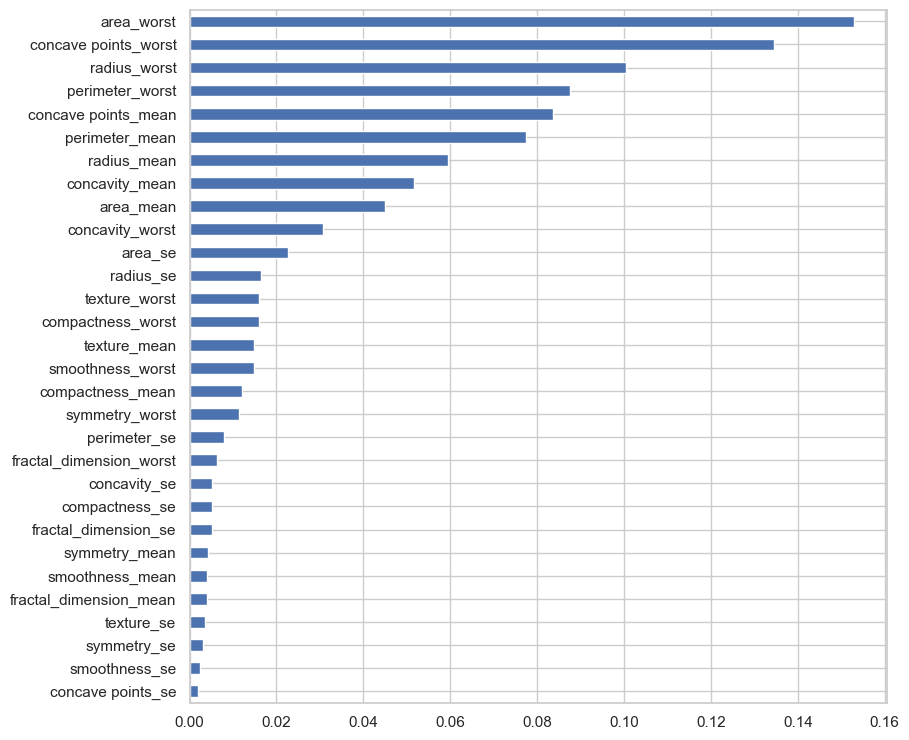

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519
2,ANOVA 5,0.939525,0.034282
3,RFE 5,0.936584,0.029225
4,SFM mediana,0.951858,0.025664


['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'concavity_mean',
 'concave points_mean',
 'radius_se',
 'area_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst']

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519
2,ANOVA 5,0.939525,0.034282
3,RFE 5,0.936584,0.029225
4,SFM mediana,0.951858,0.025664
5,SFM top5,0.938906,0.037168


['concave points_mean',
 'radius_worst',
 'perimeter_worst',
 'area_worst',
 'concave points_worst']

In [12]:
pd.Series(baseline.feature_importances_,index=X_train.columns).sort_values().plot.barh(figsize=(9,9)); plt.show()
for threshold,limit,name in [('median',None,'SFM mediana'),(-np.inf,5,'SFM top5')]:
    selector=SelectFromModel(clone(rf),threshold=threshold,max_features=limit)
    model=make_pipeline(selector,StandardScaler(),LogisticRegression(max_iter=3000))
    model=evaluate(name,model)
    display(X_train.columns[model.steps[0][1].get_support()].tolist())

### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.

In [13]:
selector=RFECV(clone(rf),step=2,cv=StratifiedKFold(3,shuffle=True,random_state=SEED),scoring='balanced_accuracy',min_features_to_select=1)
rfecv=evaluate('RFECV anidado',make_pipeline(selector,clone(rf)))
display(X_train.columns[rfecv.steps[0][1].get_support()].tolist())
print('Número elegido:',rfecv.steps[0][1].n_features_)
print('Test RFECV:',balanced_accuracy_score(y_test,rfecv.predict(X_test)))
display(pd.DataFrame(results).sort_values('CV',ascending=False))
print('La selección automática se incluye dentro del pipeline. RFECV usa CV interna y se evalúa con folds externos; diferencias pequeñas requieren prudencia con 114 casos de test.')

,metodo,CV,CV_std
0,Todas,0.963003,0.023833
1,Visual + correlación,0.915428,0.016519
2,ANOVA 5,0.939525,0.034282
3,RFE 5,0.936584,0.029225
4,SFM mediana,0.951858,0.025664
5,SFM top5,0.938906,0.037168
6,RFECV anidado,0.957121,0.026840


['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'concavity_mean',
 'concave points_mean',
 'area_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst']

Número elegido: 16
Test RFECV: 0.9642857142857143


,metodo,CV,CV_std
0,Todas,0.963003,0.023833
6,RFECV anidado,0.957121,0.026840
4,SFM mediana,0.951858,0.025664
2,ANOVA 5,0.939525,0.034282
5,SFM top5,0.938906,0.037168
3,RFE 5,0.936584,0.029225
1,Visual + correlación,0.915428,0.016519


La selección automática se incluye dentro del pipeline. RFECV usa CV interna y se evalúa con folds externos; diferencias pequeñas requieren prudencia con 114 casos de test.
